In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader

from torchvision import datasets, models
from torchvision.transforms import transforms

from captum.attr import IntegratedGradients, Occlusion
from sklearn.metrics import auc

In [28]:
model_path = Path("../models/resnet18_cifar10_trained.pth")
data_path = Path("../data/")

In [29]:
def get_device():
    return torch.device("cuda")


def load_model(model_path, num_classes=10):
    device = get_device()

    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)

    model = model.to(device)
    model.eval()

    return model


def get_test_data():
    transform = transforms.Compose(
        [
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    )

    return datasets.CIFAR10(
        root="../data", download=False, train=False, transform=transform
    )


def tensor_to_img(tensor):
    # Remove batch dimension (if exists) and move to CPU
    img_np = tensor.squeeze(0).detach().cpu().numpy()

    # Handle channel dimensions (C, H, W) -> (H, W, C)
    if img_np.ndim == 3:
        if img_np.shape[0] == 1:
            img_np = img_np.squeeze(0)  # Grayscale conversion
        else:
            img_np = np.transpose(img_np, (1, 2, 0))  # RGB conversion

    # Denormalize from [-1, 1] to [0, 1] for visual display
    img_np = (img_np + 1) / 2
    img_np = np.clip(img_np, 0, 1)

    return img_np


def fgsm_attack(model, input_tensor, target_class, epsilon):
    device = get_device()
    x = input_tensor.clone().detach().to(device)
    x.requires_grad = True

    output = model(x)
    loss = torch.nn.functional.cross_entropy(
        output, torch.tensor([target_class], device=device)
    )

    model.zero_grad()
    loss.backward()

    perturbation = epsilon * x.grad.sign()
    x_adv = x + perturbation

    # bo obrazy masz w zakresie [-1, 1]
    x_adv = torch.clamp(x_adv, -1.0, 1.0)

    return x_adv.detach()


def process_attribution_raw(attr_tensor):
    attr_np = attr_tensor.squeeze(0).detach().cpu().numpy()

    if attr_np.ndim == 3:
        attr_np = np.sum(attr_np, axis=0)

    return attr_np


def plot_image(ax, img, title, cmap=None):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")


def cosine_sim(a, b):
    a = a.flatten()
    b = b.flatten()

    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8)


def topk_iou(a, b, top_k_percent=0.10):
    a = a.flatten()
    b = b.flatten()

    k = int(len(a) * top_k_percent)

    # Top-K największych wartości RAW attribution
    top_a = np.argpartition(a, -k)[-k:]
    top_b = np.argpartition(b, -k)[-k:]

    set_a = set(top_a)
    set_b = set(top_b)

    intersection = len(set_a & set_b)
    union = len(set_a | set_b)

    return intersection / (union + 1e-8)


def deletion_auc(
    model,
    input_tensor,
    attribution_map,
    target_class,
    steps=20,
    baseline_value=-1.0,
):
    """
    Deletion AUC dla jednej próbki.

    Usuwa piksele według największych DODATNICH atrybucji,
    czyli tych, które wspierają target_class.
    """

    x_deleted = input_tensor.clone().detach()
    _, C, H, W = x_deleted.shape

    total_pixels = H * W

    # RAW attribution -> flatten
    attr_flat = attribution_map.flatten()

    # Bierzemy tylko dodatnie atrybucje jako importance
    # bo deletion ma usuwać piksele wspierające target class
    importance = np.maximum(attr_flat, 0)

    # Jeśli przypadkiem wszystko byłoby zerowe lub ujemne,
    # fallback na surowe wartości dodatnie nie zadziała, więc używamy abs awaryjnie
    if np.all(importance == 0):
        importance = np.abs(attr_flat)

    # Indeksy od najbardziej do najmniej ważnych
    sorted_indices = np.argsort(importance)[::-1]

    confidences = []
    fractions_removed = []

    with torch.no_grad():
        for step in range(steps + 1):
            fraction_removed = step / steps

            # Mierzymy confidence aktualnego obrazu
            output = model(x_deleted)
            prob = torch.softmax(output, dim=1)[0, target_class].item()

            confidences.append(prob)
            fractions_removed.append(fraction_removed)

            if step == steps:
                break

            start = int((step / steps) * total_pixels)
            end = int(((step + 1) / steps) * total_pixels)

            pixels_to_remove = sorted_indices[start:end]

            rows = pixels_to_remove // W
            cols = pixels_to_remove % W

            # Usuwamy piksele we wszystkich kanałach
            x_deleted[:, :, rows, cols] = baseline_value

    deletion_score = auc(fractions_removed, confidences)

    return deletion_score

In [30]:
device = get_device()
model = load_model(model_path=model_path)
test_data = get_test_data()
ig = IntegratedGradients(model)
occlusion = Occlusion(model)

In [31]:
selected_classes = [0, 1, 2, 3]

class_names = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

min_confidence = 0.99
max_candidates_per_class = 5

In [32]:
candidate_examples = {class_id: [] for class_id in selected_classes}

model.eval()

for image, label in test_data:
    if label not in selected_classes:
        continue

    if len(candidate_examples[label]) >= max_candidates_per_class:
        continue

    tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)

        pred = output.argmax(dim=1).item()
        conf = probs[0, pred].item()

    if pred == label and conf >= min_confidence:
        candidate_examples[label].append(
            {
                "image": image,
                "conf": conf,
            }
        )

        print(
            f"Candidate | "
            f"TRUE: {class_names[label]} | "
            f"PRED: {class_names[pred]} | "
            f"CONF: {conf:.3f} | "
            f"count={len(candidate_examples[label])}"
        )

    if all(
        len(candidate_examples[class_id]) >= max_candidates_per_class
        for class_id in selected_classes
    ):
        break

print("\nCollected candidates:")
for class_id in selected_classes:
    print(f"{class_names[class_id]}: {len(candidate_examples[class_id])}")

Candidate | TRUE: cat | PRED: cat | CONF: 0.999 | count=1
Candidate | TRUE: airplane | PRED: airplane | CONF: 1.000 | count=1
Candidate | TRUE: automobile | PRED: automobile | CONF: 0.999 | count=1
Candidate | TRUE: cat | PRED: cat | CONF: 1.000 | count=2
Candidate | TRUE: automobile | PRED: automobile | CONF: 1.000 | count=2
Candidate | TRUE: airplane | PRED: airplane | CONF: 1.000 | count=2
Candidate | TRUE: airplane | PRED: airplane | CONF: 1.000 | count=3
Candidate | TRUE: airplane | PRED: airplane | CONF: 1.000 | count=4
Candidate | TRUE: airplane | PRED: airplane | CONF: 1.000 | count=5
Candidate | TRUE: bird | PRED: bird | CONF: 1.000 | count=1
Candidate | TRUE: automobile | PRED: automobile | CONF: 1.000 | count=3
Candidate | TRUE: bird | PRED: bird | CONF: 1.000 | count=2
Candidate | TRUE: bird | PRED: bird | CONF: 0.999 | count=3
Candidate | TRUE: bird | PRED: bird | CONF: 1.000 | count=4
Candidate | TRUE: cat | PRED: cat | CONF: 1.000 | count=3
Candidate | TRUE: automobile |

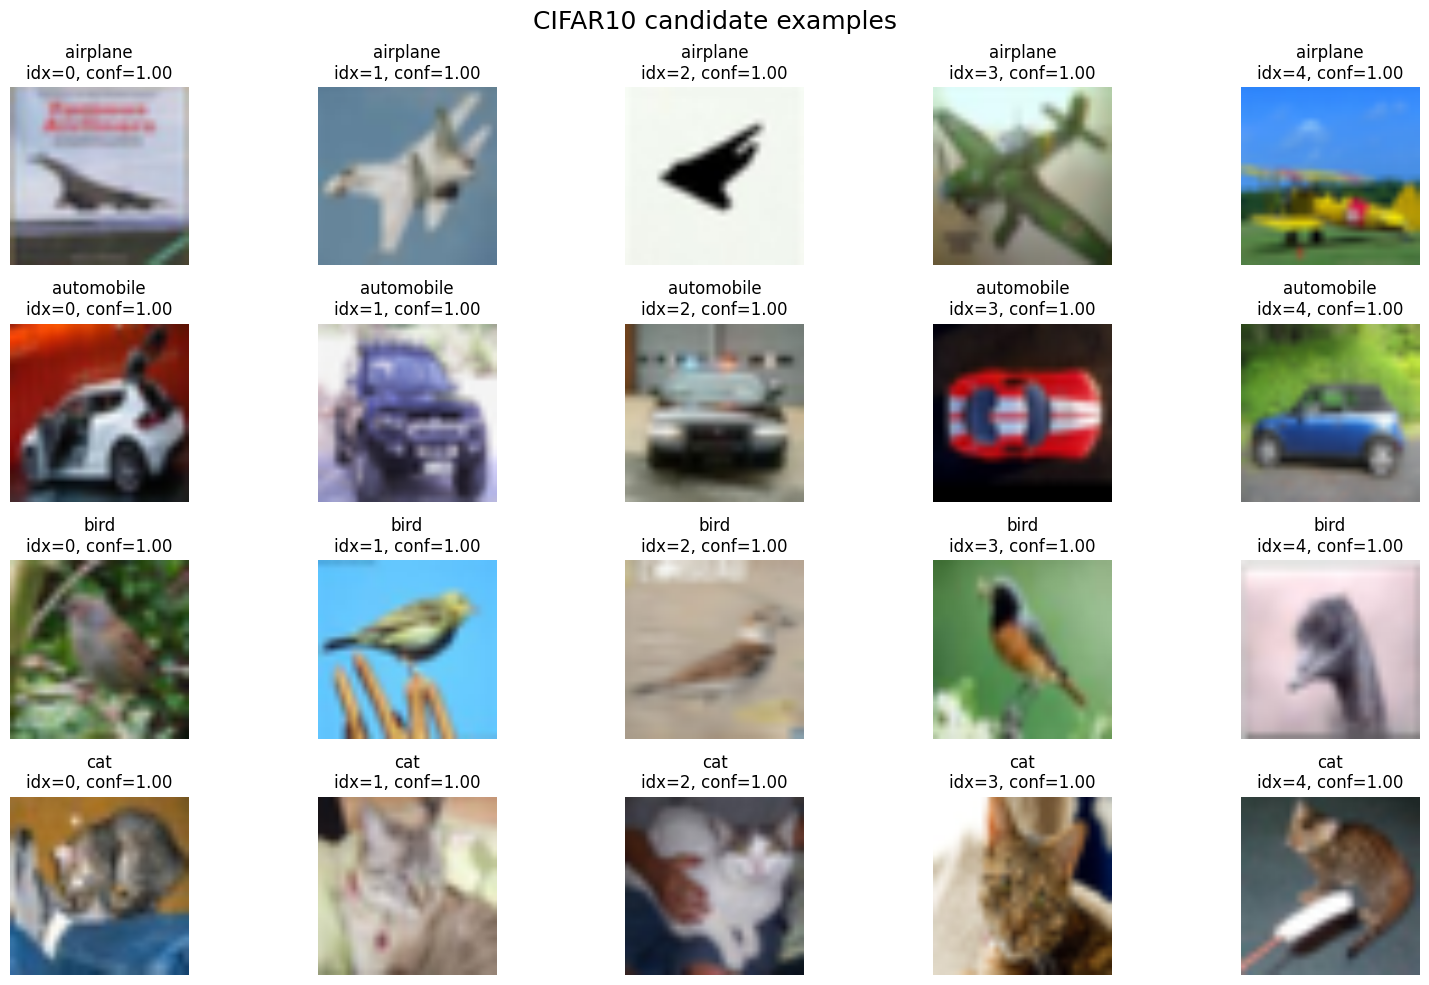

In [33]:
fig, axes = plt.subplots(
    len(selected_classes),
    max_candidates_per_class,
    figsize=(16, 10),
)

fig.suptitle("CIFAR10 candidate examples", fontsize=18)

for row, class_id in enumerate(selected_classes):
    for col in range(max_candidates_per_class):
        if col >= len(candidate_examples[class_id]):
            axes[row, col].axis("off")
            continue

        image = candidate_examples[class_id][col]["image"]
        conf = candidate_examples[class_id][col]["conf"]

        img = tensor_to_img(image)

        plot_image(
            axes[row, col],
            img,
            title=(f"{class_names[class_id]}\nidx={col}, conf={conf:.2f}"),
            cmap=None,
        )

plt.tight_layout()
plt.show()

In [34]:
chosen_indices = {
    0: 1,
    1: 0,
    2: 1,
    3: 4,
}

clean_examples = {
    class_id: candidate_examples[class_id][chosen_indices[class_id]]["image"]
    for class_id in selected_classes
}

In [35]:
print("=== FINAL CLEAN EXAMPLES SANITY CHECK ===")

for class_id in selected_classes:
    tensor = clean_examples[class_id].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)

        pred = output.argmax(dim=1).item()
        conf = probs[0, pred].item()

    print(
        f"TRUE: {class_names[class_id]} | PRED: {class_names[pred]} | CONF: {conf:.3f}"
    )

=== FINAL CLEAN EXAMPLES SANITY CHECK ===
TRUE: airplane | PRED: airplane | CONF: 1.000
TRUE: automobile | PRED: automobile | CONF: 0.999
TRUE: bird | PRED: bird | CONF: 1.000
TRUE: cat | PRED: cat | CONF: 1.000


In [50]:
epsilon = 0.1

selected_classes = sorted(clean_examples.keys())

attacked_examples = {}

for class_id in selected_classes:
    clean_tensor = clean_examples[class_id].unsqueeze(0).to(device)

    attacked_tensor = fgsm_attack(
        model=model,
        input_tensor=clean_tensor,
        target_class=class_id,
        epsilon=epsilon,
    )

    attacked_examples[class_id] = attacked_tensor.squeeze(0).detach().cpu()

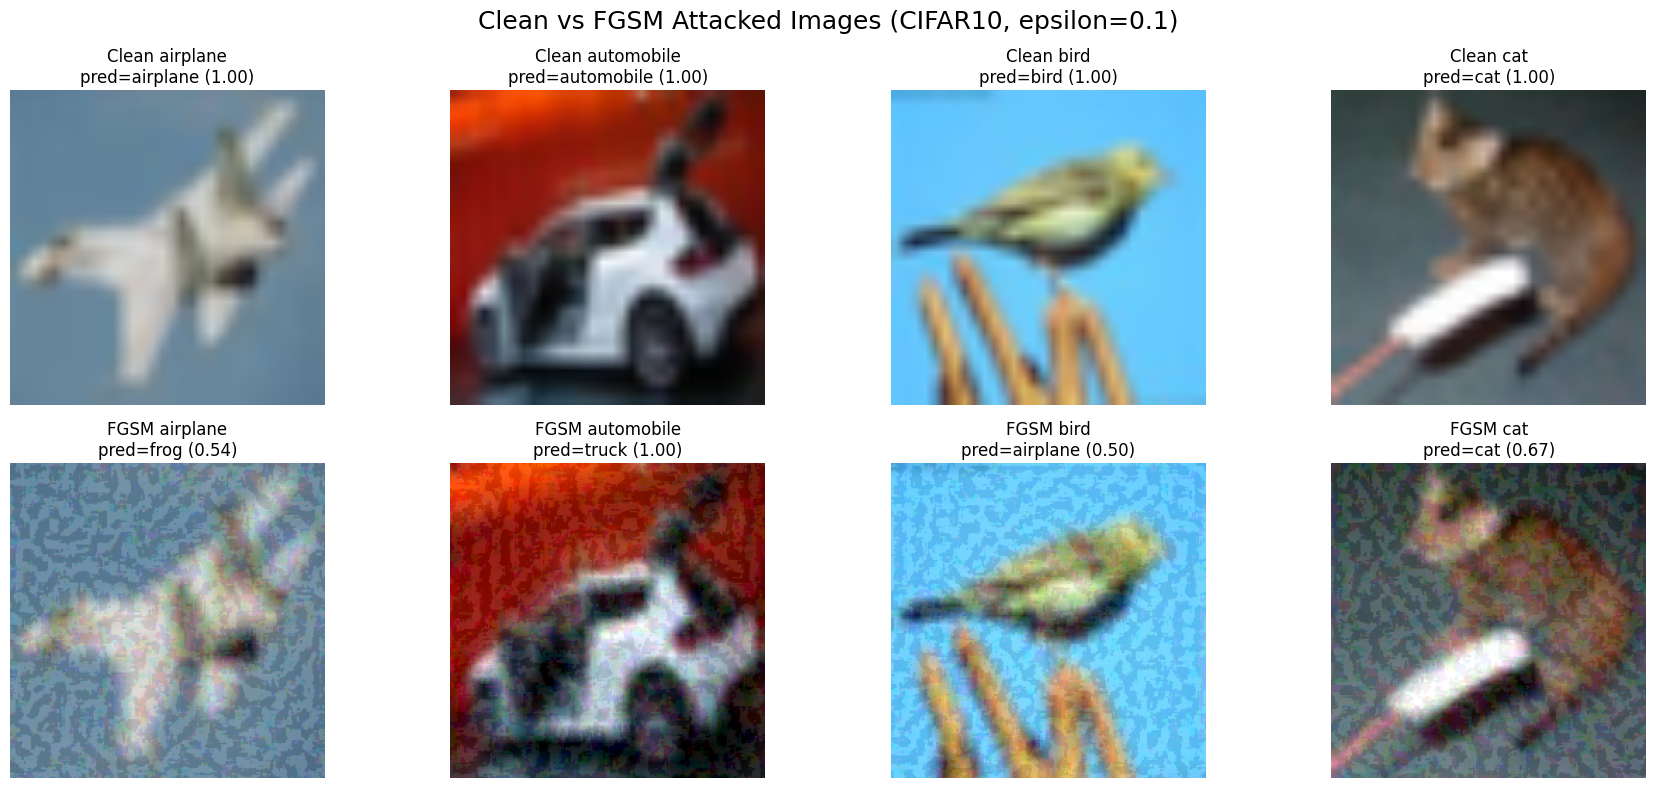

In [51]:
fig, axes = plt.subplots(
    2,
    len(selected_classes),
    figsize=(18, 8),
)

fig.suptitle(
    f"Clean vs FGSM Attacked Images (CIFAR10, epsilon={epsilon})",
    fontsize=18,
)

for idx, class_id in enumerate(selected_classes):
    clean_tensor = clean_examples[class_id].unsqueeze(0).to(device)
    attacked_tensor = attacked_examples[class_id].unsqueeze(0).to(device)

    with torch.no_grad():
        clean_output = model(clean_tensor)
        attacked_output = model(attacked_tensor)

        clean_pred = clean_output.argmax(dim=1).item()
        attacked_pred = attacked_output.argmax(dim=1).item()

        clean_conf = torch.softmax(clean_output, dim=1)[0, clean_pred].item()
        attacked_conf = torch.softmax(attacked_output, dim=1)[0, attacked_pred].item()

    clean_img = tensor_to_img(clean_tensor)
    attacked_img = tensor_to_img(attacked_tensor)

    plot_image(
        axes[0, idx],
        clean_img,
        title=(
            f"Clean {class_names[class_id]}\n"
            f"pred={class_names[clean_pred]} ({clean_conf:.2f})"
        ),
        cmap=None,
    )

    plot_image(
        axes[1, idx],
        attacked_img,
        title=(
            f"FGSM {class_names[class_id]}\n"
            f"pred={class_names[attacked_pred]} ({attacked_conf:.2f})"
        ),
        cmap=None,
    )

plt.tight_layout()
plt.show()

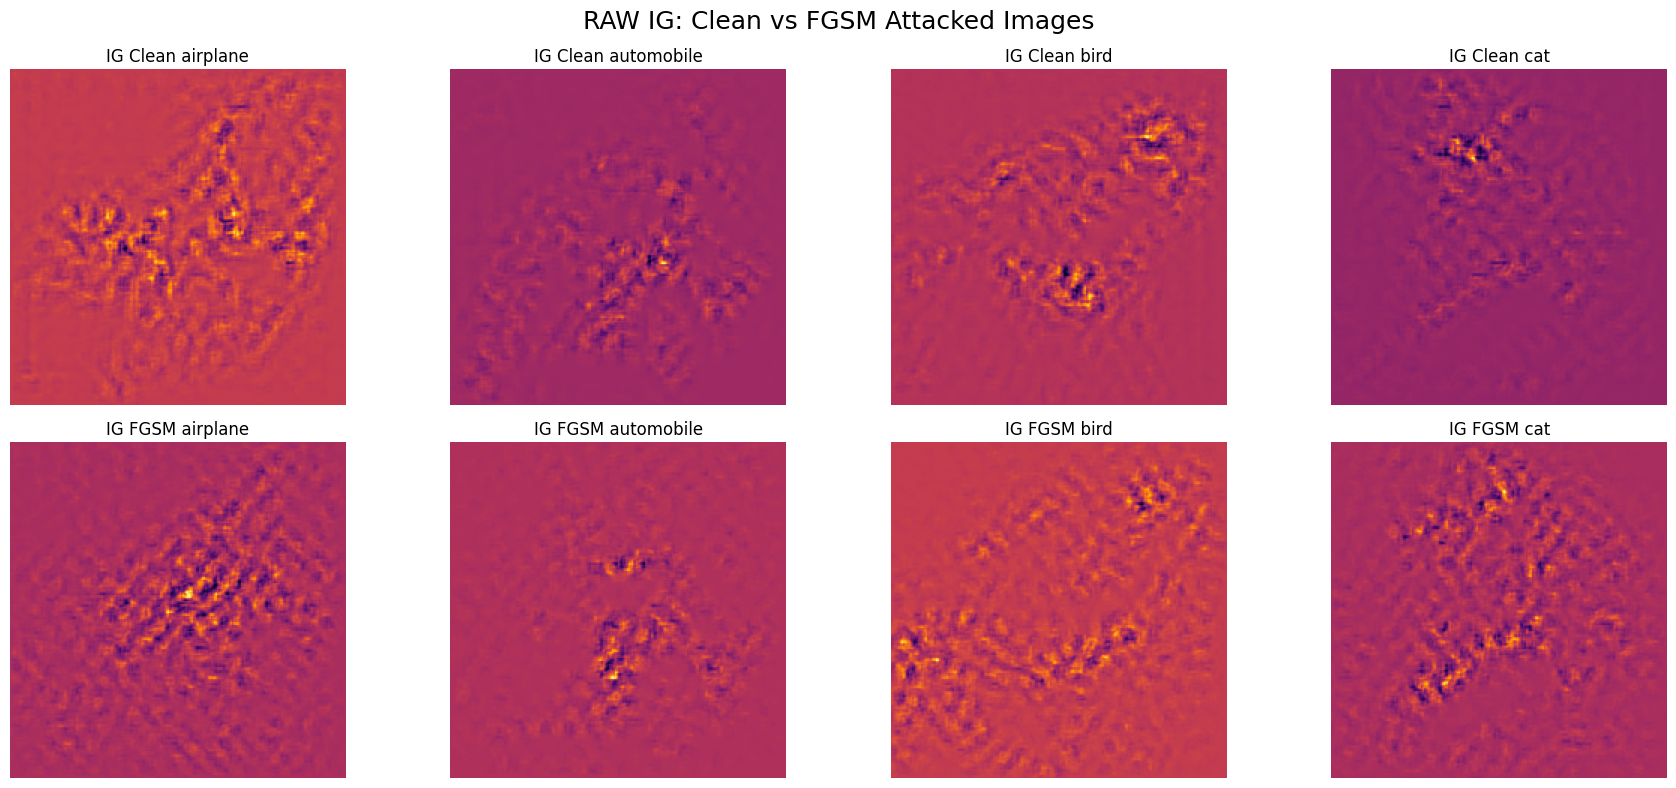

In [52]:
selected_classes = sorted(clean_examples.keys())

fig, axes = plt.subplots(
    2,
    len(selected_classes),
    figsize=(18, 8),
)

fig.suptitle(
    "RAW IG: Clean vs FGSM Attacked Images",
    fontsize=18,
)

for idx, class_id in enumerate(selected_classes):
    # =========================
    # 1. CLEAN IMAGE -> IG
    # =========================
    clean_tensor = clean_examples[class_id].unsqueeze(0).to(device)
    baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)

    attr_clean_raw = ig.attribute(
        clean_tensor,
        baselines=baseline_clean,
        target=class_id,
        n_steps=50,
    )

    clean_attr_np = process_attribution_raw(attr_clean_raw)

    plot_image(
        axes[0, idx],
        clean_attr_np,
        title=f"IG Clean {class_names[class_id]}",
        cmap="inferno",
    )

    # =========================
    # 2. WCZEŚNIEJ WYGNEROWANY FGSM IMAGE -> IG
    # =========================
    attacked_tensor = attacked_examples[class_id].unsqueeze(0).to(device)
    baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

    attr_attacked_raw = ig.attribute(
        attacked_tensor,
        baselines=baseline_attacked,
        target=class_id,
        n_steps=50,
    )

    attacked_attr_np = process_attribution_raw(attr_attacked_raw)

    plot_image(
        axes[1, idx],
        attacked_attr_np,
        title=f"IG FGSM {class_names[class_id]}",
        cmap="inferno",
    )

plt.tight_layout()
plt.show()

In [53]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1]

selected_classes = sorted(clean_examples.keys())

all_cifar_ig_fgsm_cosine_results = []

for epsilon in epsilon_values:
    print(f"Processing epsilon={epsilon}")

    for class_id in selected_classes:
        clean_tensor = clean_examples[class_id].unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=class_id,
            epsilon=epsilon,
        )

        baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)
        baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

        # --- IG CLEAN ---
        attr_clean_raw = ig.attribute(
            clean_tensor,
            baselines=baseline_clean,
            target=class_id,
            n_steps=50,
        )

        # --- IG FGSM ---
        attr_attacked_raw = ig.attribute(
            attacked_tensor,
            baselines=baseline_attacked,
            target=class_id,
            n_steps=50,
        )

        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        score = cosine_sim(clean_attr_np, attacked_attr_np)

        all_cifar_ig_fgsm_cosine_results.append(
            {
                "Epsilon": epsilon,
                "ClassID": class_id,
                "ClassName": class_names[class_id],
                "CosineSimilarity": score,
            }
        )

df_cifar_ig_fgsm_cosine = pd.DataFrame(all_cifar_ig_fgsm_cosine_results)

df_cifar_ig_fgsm_cosine_pivot = df_cifar_ig_fgsm_cosine.pivot(
    index="Epsilon",
    columns="ClassName",
    values="CosineSimilarity",
)

df_cifar_ig_fgsm_cosine_summary = (
    df_cifar_ig_fgsm_cosine.groupby("Epsilon")["CosineSimilarity"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(
        columns={
            "mean": "MeanCosineSimilarity",
            "std": "StdCosineSimilarity",
        }
    )
)

print("=== CIFAR10 + IG + FGSM: Cosine Similarity per class ===")
display(df_cifar_ig_fgsm_cosine_pivot.round(3))

print("\n=== CIFAR10 + IG + FGSM: Cosine Similarity summary ===")
display(df_cifar_ig_fgsm_cosine_summary.round(3))

Processing epsilon=0.001
Processing epsilon=0.005
Processing epsilon=0.01
Processing epsilon=0.05
Processing epsilon=0.1
=== CIFAR10 + IG + FGSM: Cosine Similarity per class ===


ClassName,airplane,automobile,bird,cat
Epsilon,,,,
0.001,0.946,0.975,0.955,0.974
0.005,0.720,0.861,0.781,0.864
0.010,0.517,0.729,0.582,0.660
0.050,-0.012,0.116,0.065,0.118
0.100,-0.069,-0.081,-0.030,0.015



=== CIFAR10 + IG + FGSM: Cosine Similarity summary ===


,Epsilon,MeanCosineSimilarity,StdCosineSimilarity
0,0.001,0.963,0.014
1,0.005,0.806,0.069
2,0.010,0.622,0.092
3,0.050,0.072,0.061
4,0.100,-0.041,0.043


In [54]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1]

selected_classes = sorted(clean_examples.keys())

all_cifar_ig_fgsm_iou_results = []

for epsilon in epsilon_values:
    print(f"Processing epsilon={epsilon}")

    for class_id in selected_classes:
        clean_tensor = clean_examples[class_id].unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=class_id,
            epsilon=epsilon,
        )

        baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)
        baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

        # --- IG CLEAN ---
        attr_clean_raw = ig.attribute(
            clean_tensor,
            baselines=baseline_clean,
            target=class_id,
            n_steps=50,
        )

        # --- IG FGSM ---
        attr_attacked_raw = ig.attribute(
            attacked_tensor,
            baselines=baseline_attacked,
            target=class_id,
            n_steps=50,
        )

        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        iou_score = topk_iou(
            clean_attr_np,
            attacked_attr_np,
            top_k_percent=0.10,
        )

        all_cifar_ig_fgsm_iou_results.append(
            {
                "Epsilon": epsilon,
                "ClassID": class_id,
                "ClassName": class_names[class_id],
                "TopK_IoU": iou_score,
            }
        )

df_cifar_ig_fgsm_iou = pd.DataFrame(all_cifar_ig_fgsm_iou_results)

df_cifar_ig_fgsm_iou_pivot = df_cifar_ig_fgsm_iou.pivot(
    index="Epsilon",
    columns="ClassName",
    values="TopK_IoU",
)

df_cifar_ig_fgsm_iou_summary = (
    df_cifar_ig_fgsm_iou.groupby("Epsilon")["TopK_IoU"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(
        columns={
            "mean": "MeanTopK_IoU",
            "std": "StdTopK_IoU",
        }
    )
)

print("=== CIFAR10 + IG + FGSM: Top-K IoU per class ===")
display(df_cifar_ig_fgsm_iou_pivot.round(3))

print("\n=== CIFAR10 + IG + FGSM: Top-K IoU summary ===")
display(df_cifar_ig_fgsm_iou_summary.round(3))

Processing epsilon=0.001
Processing epsilon=0.005
Processing epsilon=0.01
Processing epsilon=0.05
Processing epsilon=0.1
=== CIFAR10 + IG + FGSM: Top-K IoU per class ===


ClassName,airplane,automobile,bird,cat
Epsilon,,,,
0.001,0.719,0.835,0.734,0.792
0.005,0.399,0.578,0.464,0.551
0.010,0.265,0.441,0.334,0.390
0.050,0.115,0.174,0.146,0.172
0.100,0.088,0.107,0.099,0.122



=== CIFAR10 + IG + FGSM: Top-K IoU summary ===


,Epsilon,MeanTopK_IoU,StdTopK_IoU
0,0.001,0.770,0.054
1,0.005,0.498,0.082
2,0.010,0.358,0.076
3,0.050,0.151,0.028
4,0.100,0.104,0.014


In [55]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1]

selected_classes = sorted(clean_examples.keys())

all_cifar_ig_fgsm_deletion_results = []

for epsilon in epsilon_values:
    print(f"Processing epsilon={epsilon}")

    for class_id in selected_classes:
        clean_tensor = clean_examples[class_id].unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=class_id,
            epsilon=epsilon,
        )

        baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)
        baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

        # --- PREDICTIONS / CONFIDENCE ---
        with torch.no_grad():
            clean_output = model(clean_tensor)
            attacked_output = model(attacked_tensor)

            clean_pred = clean_output.argmax(dim=1).item()
            attacked_pred = attacked_output.argmax(dim=1).item()

            clean_conf = torch.softmax(clean_output, dim=1)[0, class_id].item()
            attacked_conf = torch.softmax(attacked_output, dim=1)[0, class_id].item()

        # --- IG CLEAN ---
        attr_clean_raw = ig.attribute(
            clean_tensor,
            baselines=baseline_clean,
            target=class_id,
            n_steps=50,
        )

        # --- IG FGSM ---
        attr_attacked_raw = ig.attribute(
            attacked_tensor,
            baselines=baseline_attacked,
            target=class_id,
            n_steps=50,
        )

        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        # --- DELETION AUC CLEAN ---
        deletion_clean = deletion_auc(
            model=model,
            input_tensor=clean_tensor,
            attribution_map=clean_attr_np,
            target_class=class_id,
            steps=20,
            baseline_value=-1.0,
        )

        # --- DELETION AUC FGSM ---
        deletion_attacked = deletion_auc(
            model=model,
            input_tensor=attacked_tensor,
            attribution_map=attacked_attr_np,
            target_class=class_id,
            steps=20,
            baseline_value=-1.0,
        )

        all_cifar_ig_fgsm_deletion_results.append(
            {
                "Epsilon": epsilon,
                "ClassID": class_id,
                "ClassName": class_names[class_id],
                "CleanPred": clean_pred,
                "AttackedPred": attacked_pred,
                "PredictionChanged": clean_pred != attacked_pred,
                "CleanConfidence": clean_conf,
                "AttackedConfidence": attacked_conf,
                "DeletionAUC_Clean": deletion_clean,
                "DeletionAUC_Attacked": deletion_attacked,
            }
        )

df_cifar_ig_fgsm_deletion = pd.DataFrame(all_cifar_ig_fgsm_deletion_results)

df_cifar_ig_fgsm_deletion_attacked_pivot = df_cifar_ig_fgsm_deletion.pivot(
    index="Epsilon",
    columns="ClassName",
    values="DeletionAUC_Attacked",
)

df_cifar_ig_fgsm_deletion_summary = df_cifar_ig_fgsm_deletion.groupby("Epsilon").agg(
    CleanAUC_Mean=("DeletionAUC_Clean", "mean"),
    CleanAUC_Std=("DeletionAUC_Clean", "std"),
    AttackedAUC_Mean=("DeletionAUC_Attacked", "mean"),
    AttackedAUC_Std=("DeletionAUC_Attacked", "std"),
    AttackedConfidence_Mean=("AttackedConfidence", "mean"),
    PredictionChanges=("PredictionChanged", "sum"),
)

print("=== CIFAR10 + IG + FGSM: Deletion AUC per class ===")
display(df_cifar_ig_fgsm_deletion_attacked_pivot.round(3))

print("\n=== CIFAR10 + IG + FGSM: Deletion AUC summary ===")
display(df_cifar_ig_fgsm_deletion_summary.round(3))

Processing epsilon=0.001
Processing epsilon=0.005
Processing epsilon=0.01
Processing epsilon=0.05
Processing epsilon=0.1
=== CIFAR10 + IG + FGSM: Deletion AUC per class ===


ClassName,airplane,automobile,bird,cat
Epsilon,,,,
0.001,0.682,0.515,0.038,0.122
0.005,0.686,0.470,0.035,0.112
0.010,0.613,0.386,0.013,0.156
0.050,0.503,0.244,0.015,0.166
0.100,0.553,0.226,0.011,0.181



=== CIFAR10 + IG + FGSM: Deletion AUC summary ===


,CleanAUC_Mean,CleanAUC_Std,AttackedAUC_Mean,AttackedAUC_Std,AttackedConfidence_Mean,PredictionChanges
Epsilon,,,,,,
0.001,0.338,0.302,0.339,0.309,0.997,0
0.005,0.338,0.302,0.326,0.306,0.565,1
0.010,0.338,0.302,0.292,0.263,0.286,3
0.050,0.338,0.302,0.232,0.204,0.003,4
0.100,0.338,0.302,0.243,0.227,0.169,3


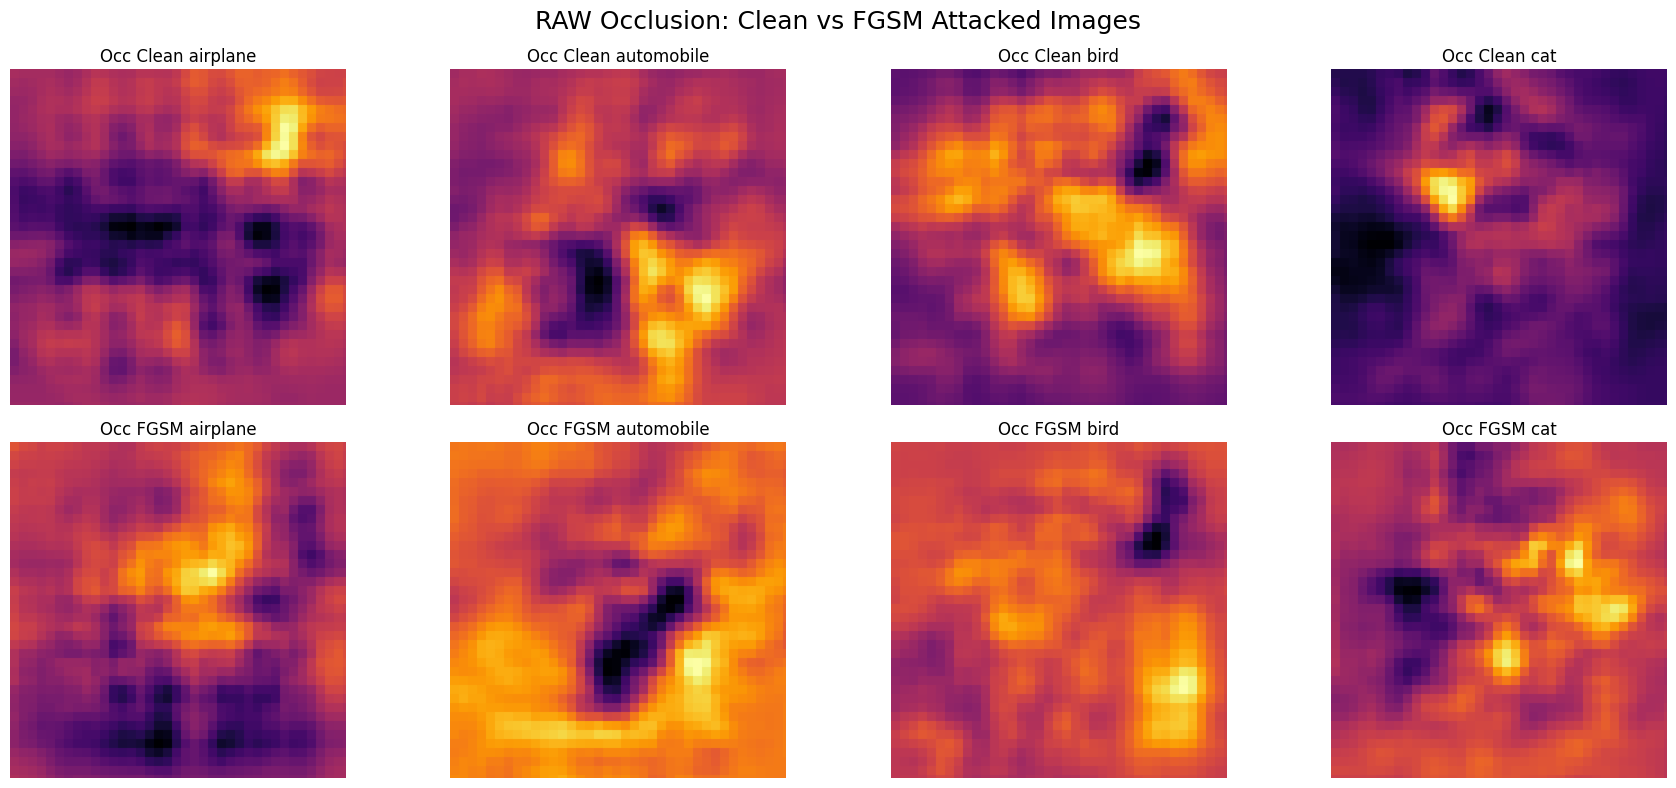

In [56]:
selected_classes = sorted(clean_examples.keys())

fig, axes = plt.subplots(
    2,
    len(selected_classes),
    figsize=(18, 8),
)

fig.suptitle(
    "RAW Occlusion: Clean vs FGSM Attacked Images",
    fontsize=18,
)

for idx, class_id in enumerate(selected_classes):
    # =========================
    # 1. OCCLUSION CLEAN
    # =========================
    clean_tensor = clean_examples[class_id].unsqueeze(0).to(device)
    baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)

    attr_clean_raw = occlusion.attribute(
        clean_tensor,
        strides=(3, 6, 6),
        sliding_window_shapes=(3, 18, 18),
        baselines=baseline_clean,
        target=class_id,
    )

    clean_attr_np = process_attribution_raw(attr_clean_raw)

    plot_image(
        axes[0, idx],
        clean_attr_np,
        title=f"Occ Clean {class_names[class_id]}",
        cmap="inferno",
    )

    # =========================
    # 2. OCCLUSION FGSM
    # =========================
    attacked_tensor = attacked_examples[class_id].unsqueeze(0).to(device)
    baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

    attr_attacked_raw = occlusion.attribute(
        attacked_tensor,
        strides=(3, 6, 6),
        sliding_window_shapes=(3, 18, 18),
        baselines=baseline_attacked,
        target=class_id,
    )

    attacked_attr_np = process_attribution_raw(attr_attacked_raw)

    plot_image(
        axes[1, idx],
        attacked_attr_np,
        title=f"Occ FGSM {class_names[class_id]}",
        cmap="inferno",
    )

plt.tight_layout()
plt.show()

In [57]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1]

selected_classes = sorted(clean_examples.keys())

all_cifar_occ_fgsm_cosine_results = []

for epsilon in epsilon_values:
    print(f"Processing epsilon={epsilon}")

    for class_id in selected_classes:
        clean_tensor = clean_examples[class_id].unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=class_id,
            epsilon=epsilon,
        )

        baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)
        baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

        # --- OCCLUSION CLEAN ---
        attr_clean_raw = occlusion.attribute(
            clean_tensor,
            strides=(3, 6, 6),
            sliding_window_shapes=(3, 18, 18),
            baselines=baseline_clean,
            target=class_id,
        )

        # --- OCCLUSION FGSM ---
        attr_attacked_raw = occlusion.attribute(
            attacked_tensor,
            strides=(3, 6, 6),
            sliding_window_shapes=(3, 18, 18),
            baselines=baseline_attacked,
            target=class_id,
        )

        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        score = cosine_sim(clean_attr_np, attacked_attr_np)

        all_cifar_occ_fgsm_cosine_results.append(
            {
                "Epsilon": epsilon,
                "ClassID": class_id,
                "ClassName": class_names[class_id],
                "CosineSimilarity": score,
            }
        )

df_cifar_occ_fgsm_cosine = pd.DataFrame(all_cifar_occ_fgsm_cosine_results)

df_cifar_occ_fgsm_cosine_pivot = df_cifar_occ_fgsm_cosine.pivot(
    index="Epsilon",
    columns="ClassName",
    values="CosineSimilarity",
)

df_cifar_occ_fgsm_cosine_summary = (
    df_cifar_occ_fgsm_cosine.groupby("Epsilon")["CosineSimilarity"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(
        columns={
            "mean": "MeanCosineSimilarity",
            "std": "StdCosineSimilarity",
        }
    )
)

print("=== CIFAR10 + Occlusion + FGSM: Cosine Similarity per class ===")
display(df_cifar_occ_fgsm_cosine_pivot.round(3))

print("\n=== CIFAR10 + Occlusion + FGSM: Cosine Similarity summary ===")
display(df_cifar_occ_fgsm_cosine_summary.round(3))

Processing epsilon=0.001
Processing epsilon=0.005
Processing epsilon=0.01
Processing epsilon=0.05
Processing epsilon=0.1
=== CIFAR10 + Occlusion + FGSM: Cosine Similarity per class ===


ClassName,airplane,automobile,bird,cat
Epsilon,,,,
0.001,0.984,0.995,0.998,0.998
0.005,0.856,0.889,0.958,0.978
0.010,0.693,0.669,0.873,0.945
0.050,0.336,0.293,0.427,0.645
0.100,0.002,0.180,0.363,0.254



=== CIFAR10 + Occlusion + FGSM: Cosine Similarity summary ===


,Epsilon,MeanCosineSimilarity,StdCosineSimilarity
0,0.001,0.994,0.007
1,0.005,0.920,0.057
2,0.010,0.795,0.135
3,0.050,0.425,0.157
4,0.100,0.200,0.152


In [58]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1]

selected_classes = sorted(clean_examples.keys())

all_cifar_occ_fgsm_iou_results = []

for epsilon in epsilon_values:
    print(f"Processing epsilon={epsilon}")

    for class_id in selected_classes:
        clean_tensor = clean_examples[class_id].unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=class_id,
            epsilon=epsilon,
        )

        baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)
        baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

        # --- OCCLUSION CLEAN ---
        attr_clean_raw = occlusion.attribute(
            clean_tensor,
            strides=(3, 6, 6),
            sliding_window_shapes=(3, 18, 18),
            baselines=baseline_clean,
            target=class_id,
        )

        # --- OCCLUSION FGSM ---
        attr_attacked_raw = occlusion.attribute(
            attacked_tensor,
            strides=(3, 6, 6),
            sliding_window_shapes=(3, 18, 18),
            baselines=baseline_attacked,
            target=class_id,
        )

        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        iou_score = topk_iou(
            clean_attr_np,
            attacked_attr_np,
            top_k_percent=0.10,
        )

        all_cifar_occ_fgsm_iou_results.append(
            {
                "Epsilon": epsilon,
                "ClassID": class_id,
                "ClassName": class_names[class_id],
                "TopK_IoU": iou_score,
            }
        )

df_cifar_occ_fgsm_iou = pd.DataFrame(all_cifar_occ_fgsm_iou_results)

df_cifar_occ_fgsm_iou_pivot = df_cifar_occ_fgsm_iou.pivot(
    index="Epsilon",
    columns="ClassName",
    values="TopK_IoU",
)

df_cifar_occ_fgsm_iou_summary = (
    df_cifar_occ_fgsm_iou.groupby("Epsilon")["TopK_IoU"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(
        columns={
            "mean": "MeanTopK_IoU",
            "std": "StdTopK_IoU",
        }
    )
)

print("=== CIFAR10 + Occlusion + FGSM: Top-K IoU per class ===")
display(df_cifar_occ_fgsm_iou_pivot.round(3))

print("\n=== CIFAR10 + Occlusion + FGSM: Top-K IoU summary ===")
display(df_cifar_occ_fgsm_iou_summary.round(3))

Processing epsilon=0.001
Processing epsilon=0.005
Processing epsilon=0.01
Processing epsilon=0.05
Processing epsilon=0.1
=== CIFAR10 + Occlusion + FGSM: Top-K IoU per class ===


ClassName,airplane,automobile,bird,cat
Epsilon,,,,
0.001,0.917,0.958,0.798,0.931
0.005,0.738,0.563,0.452,0.727
0.010,0.580,0.403,0.364,0.627
0.050,0.257,0.292,0.153,0.302
0.100,0.081,0.257,0.086,0.076



=== CIFAR10 + Occlusion + FGSM: Top-K IoU summary ===


,Epsilon,MeanTopK_IoU,StdTopK_IoU
0,0.001,0.901,0.071
1,0.005,0.620,0.138
2,0.010,0.493,0.130
3,0.050,0.251,0.068
4,0.100,0.125,0.088


In [59]:
epsilon_values = [0.001, 0.005, 0.01, 0.05, 0.1]

selected_classes = sorted(clean_examples.keys())

all_cifar_occ_fgsm_deletion_results = []

for epsilon in epsilon_values:
    print(f"Processing epsilon={epsilon}")

    for class_id in selected_classes:
        clean_tensor = clean_examples[class_id].unsqueeze(0).to(device)

        attacked_tensor = fgsm_attack(
            model=model,
            input_tensor=clean_tensor,
            target_class=class_id,
            epsilon=epsilon,
        )

        baseline_clean = torch.full_like(clean_tensor, -1.0).to(device)
        baseline_attacked = torch.full_like(attacked_tensor, -1.0).to(device)

        # --- PREDICTIONS / CONFIDENCE ---
        with torch.no_grad():
            clean_output = model(clean_tensor)
            attacked_output = model(attacked_tensor)

            clean_pred = clean_output.argmax(dim=1).item()
            attacked_pred = attacked_output.argmax(dim=1).item()

            clean_conf = torch.softmax(clean_output, dim=1)[0, class_id].item()
            attacked_conf = torch.softmax(attacked_output, dim=1)[0, class_id].item()

        # --- OCCLUSION CLEAN ---
        attr_clean_raw = occlusion.attribute(
            clean_tensor,
            strides=(3, 6, 6),
            sliding_window_shapes=(3, 18, 18),
            baselines=baseline_clean,
            target=class_id,
        )

        # --- OCCLUSION FGSM ---
        attr_attacked_raw = occlusion.attribute(
            attacked_tensor,
            strides=(3, 6, 6),
            sliding_window_shapes=(3, 18, 18),
            baselines=baseline_attacked,
            target=class_id,
        )

        clean_attr_np = process_attribution_raw(attr_clean_raw)
        attacked_attr_np = process_attribution_raw(attr_attacked_raw)

        # --- DELETION AUC CLEAN ---
        deletion_clean = deletion_auc(
            model=model,
            input_tensor=clean_tensor,
            attribution_map=clean_attr_np,
            target_class=class_id,
            steps=20,
            baseline_value=-1.0,
        )

        # --- DELETION AUC FGSM ---
        deletion_attacked = deletion_auc(
            model=model,
            input_tensor=attacked_tensor,
            attribution_map=attacked_attr_np,
            target_class=class_id,
            steps=20,
            baseline_value=-1.0,
        )

        all_cifar_occ_fgsm_deletion_results.append(
            {
                "Epsilon": epsilon,
                "ClassID": class_id,
                "ClassName": class_names[class_id],
                "CleanPred": clean_pred,
                "AttackedPred": attacked_pred,
                "PredictionChanged": clean_pred != attacked_pred,
                "CleanConfidence": clean_conf,
                "AttackedConfidence": attacked_conf,
                "DeletionAUC_Clean": deletion_clean,
                "DeletionAUC_Attacked": deletion_attacked,
            }
        )

df_cifar_occ_fgsm_deletion = pd.DataFrame(all_cifar_occ_fgsm_deletion_results)

df_cifar_occ_fgsm_deletion_attacked_pivot = df_cifar_occ_fgsm_deletion.pivot(
    index="Epsilon",
    columns="ClassName",
    values="DeletionAUC_Attacked",
)

df_cifar_occ_fgsm_deletion_summary = df_cifar_occ_fgsm_deletion.groupby("Epsilon").agg(
    CleanAUC_Mean=("DeletionAUC_Clean", "mean"),
    CleanAUC_Std=("DeletionAUC_Clean", "std"),
    AttackedAUC_Mean=("DeletionAUC_Attacked", "mean"),
    AttackedAUC_Std=("DeletionAUC_Attacked", "std"),
    AttackedConfidence_Mean=("AttackedConfidence", "mean"),
    PredictionChanges=("PredictionChanged", "sum"),
)

print("=== CIFAR10 + Occlusion + FGSM: Deletion AUC per class ===")
display(df_cifar_occ_fgsm_deletion_attacked_pivot.round(3))

print("\n=== CIFAR10 + Occlusion + FGSM: Deletion AUC summary ===")
display(df_cifar_occ_fgsm_deletion_summary.round(3))

Processing epsilon=0.001
Processing epsilon=0.005
Processing epsilon=0.01
Processing epsilon=0.05
Processing epsilon=0.1
=== CIFAR10 + Occlusion + FGSM: Deletion AUC per class ===


ClassName,airplane,automobile,bird,cat
Epsilon,,,,
0.001,0.434,0.238,0.419,0.542
0.005,0.390,0.035,0.065,0.614
0.010,0.415,0.101,0.006,0.573
0.050,0.416,0.040,0.001,0.212
0.100,0.412,0.145,0.002,0.208



=== CIFAR10 + Occlusion + FGSM: Deletion AUC summary ===


,CleanAUC_Mean,CleanAUC_Std,AttackedAUC_Mean,AttackedAUC_Std,AttackedConfidence_Mean,PredictionChanges
Epsilon,,,,,,
0.001,0.47,0.15,0.408,0.126,0.997,0
0.005,0.47,0.15,0.276,0.276,0.565,1
0.010,0.47,0.15,0.274,0.265,0.286,3
0.050,0.47,0.15,0.167,0.189,0.003,4
0.100,0.47,0.15,0.191,0.170,0.169,3
